# Treinamento com interface de alto nível

## Importação das bibliotecas

In [1]:
# http://pytorch.org/
from os.path import exists

import torch

In [2]:
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR

In [3]:
use_cuda = torch.cuda.is_available()
torch.manual_seed(1111)
device = torch.device("cuda" if use_cuda else "cpu")

## Criação da rede

In [16]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.input = nn.Linear(784, 2048)
        self.drop1 = nn.Dropout(0.3)
        self.hidden = nn.Linear(2048, 9216)
        self.drop2 = nn.Dropout(0.3)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.input(x)
        x = F.relu(x)
        x = self.drop1(x)
        x = self.hidden(x)
        x = F.relu(x)
        x = self.drop2(x)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x

model = Net()

In [17]:
model

Net(
  (input): Linear(in_features=784, out_features=2048, bias=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (hidden): Linear(in_features=2048, out_features=9216, bias=True)
  (drop2): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

##Preparação dos Dados




In [18]:
train_kwargs = {'batch_size': 1000}
test_kwargs = {'batch_size': 1000}
if use_cuda:
    cuda_kwargs = {'num_workers': 1,
                    'pin_memory': True,
                    'shuffle': True}
    train_kwargs.update(cuda_kwargs)
    test_kwargs.update(cuda_kwargs)

transform=transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomRotation(15),
    transforms.Normalize((0.1307,), (0.3081,))
    ])
dataset1 = datasets.MNIST('../data', train=True, download=True,
                    transform=transform)
dataset2 = datasets.MNIST('../data', train=False,
                    transform=transform)
train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

## Treinamento

### Criando o objeto de treinamento

In [19]:
def train(model, device, train_loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    correct = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * data.size(0)
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100 * correct / len(train_loader.dataset)
    return train_loss, train_acc


In [20]:
def test(model, device, test_loader, criterion):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item() * data.size(0)
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    test_acc = 100. * correct / len(test_loader.dataset)

    return test_loss, test_acc

## Avaliação

In [21]:
epochs = 10
lr = 0.001
lr_decay = 5
patience = 5
patience_counter = 0
best_acc = 0

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

model = Net().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()
scheduler = StepLR(optimizer, step_size=lr_decay, gamma=0.5)

print("Iniciando Treinamento ...")

for epoch in range(1, epochs + 1):

  train_loss, train_acc = train(model, device, train_loader, optimizer, criterion)
  test_loss, test_acc = test(model, device, test_loader, criterion)
  scheduler.step()

  print(f"Época: {epoch} | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

  history['train_loss'].append(train_loss)
  history['train_acc'].append(train_acc)
  history['test_loss'].append(test_loss)
  history['test_acc'].append(test_acc)

  if test_acc > best_acc:
    best_acc = test_acc
    print("Salvando melhor época ...")
    torch.save(model.state_dict(), "mnist_cnn.pt")
    patience_counter = 0
  else:
    patience_counter += 1
    if patience_counter == patience:
      print(f"Parando Treinamento por Patience na época {epoch}...")
      break

Iniciando Treinamento ...
Época: 1 | Train Loss: 0.4807, Train Acc: 84.46% | Test Loss: 0.1442, Test Acc: 95.44%
Salvando melhor época ...
Época: 2 | Train Loss: 0.1348, Train Acc: 95.90% | Test Loss: 0.0999, Test Acc: 96.63%
Salvando melhor época ...
Época: 3 | Train Loss: 0.1057, Train Acc: 96.71% | Test Loss: 0.0867, Test Acc: 97.27%
Salvando melhor época ...
Época: 4 | Train Loss: 0.0883, Train Acc: 97.23% | Test Loss: 0.0852, Test Acc: 97.25%
Época: 5 | Train Loss: 0.0764, Train Acc: 97.59% | Test Loss: 0.0759, Test Acc: 97.69%
Salvando melhor época ...
Época: 6 | Train Loss: 0.0560, Train Acc: 98.26% | Test Loss: 0.0591, Test Acc: 98.20%
Salvando melhor época ...
Época: 7 | Train Loss: 0.0459, Train Acc: 98.55% | Test Loss: 0.0545, Test Acc: 98.41%
Salvando melhor época ...
Época: 8 | Train Loss: 0.0442, Train Acc: 98.61% | Test Loss: 0.0566, Test Acc: 98.07%
Época: 9 | Train Loss: 0.0398, Train Acc: 98.76% | Test Loss: 0.0549, Test Acc: 98.30%
Época: 10 | Train Loss: 0.0378, Tra

## Visualização dos Resultados

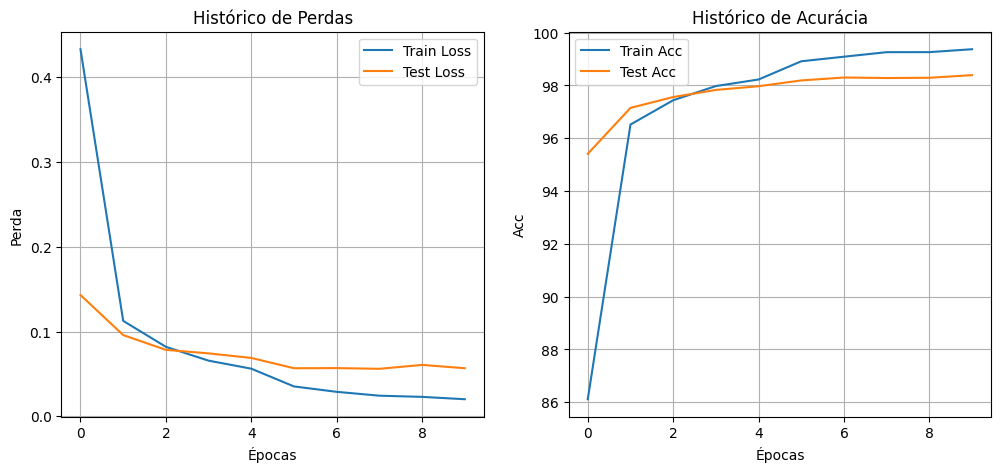

In [15]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 5))

#Perda
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['test_loss'], label='Test Loss')
plt.title('Histórico de Perdas')
plt.xlabel('Épocas')
plt.ylabel('Perda')
plt.legend()
plt.grid(True)

#Acurácia
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['test_acc'], label='Test Acc')
plt.title('Histórico de Acurácia')
plt.xlabel('Épocas')
plt.ylabel('Acc')
plt.legend()
plt.grid(True)

plt.show()

#Precisão